# Test Automatic Order Extraction Algo  
1. Refer notebook Automate Order Extraction.ipynb  
2. Global Order (itr_test.bz2) and Local Order (loc_test.bz2) data is collected using the notebook
3. Find iteration with atleast 2 transitions
4. Plot each transition with respective local order data  

- Verified that local order data is collected for respective transition only

In [1]:
%reload_ext autoreload
%autoreload 2

from tes.data_ingestion import DataRead
from tes.analysis import AnalysisFunc

import matplotlib.pyplot as plt

import numpy as np
import pandas as pd

In [2]:
analyse=AnalysisFunc()
reader=DataRead()

In [3]:
df_itr=reader.data_read_bz2('itr_test.bz2')
df_loc=reader.data_read_bz2('loc_test.bz2')

In [4]:
params= analyse.compute_param(df_itr,0.05)

Number of transitions / 100 iteration [0, 13]
Number of transition [1, 2, 4, 5, 6, 7, 8, 9]
Number of transition with more than one transition [2, 4, 5, 7]


In [5]:
n=7
smooth = np.array(analyse.smooth(df_itr[n]))

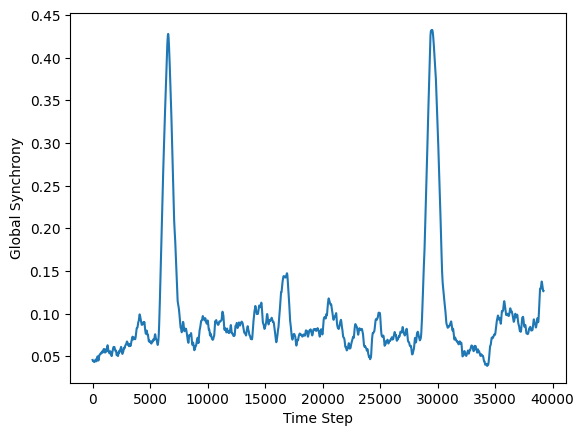

In [6]:
plt.figure(num=1,clear=True)
plt.plot(list(range(0,smooth.shape[0])),smooth)
plt.xlabel('Time Step')
plt.ylabel('Global Synchrony')
plt.show()

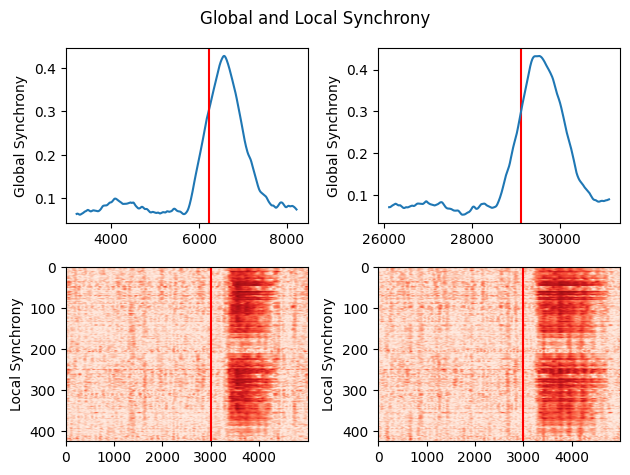

In [7]:
fig,ax = plt.subplots(2,2)

# plot 1st transition
cross = np.where(smooth>0.3)[0][0]
ax[0,0].plot(list(range(cross-3000,cross+2000)),smooth[cross-3000:cross+2000])
ax[0,0].axvline(cross,color='r')
ax[0,0].set_ylabel('Global Synchrony') 

ax[1,0].imshow(df_loc.loc[n].iloc[0:426].values,cmap='Reds',aspect='auto')
ax[1,0].set_ylabel('Local Synchrony')
ax[1,0].axvline(3000,color='r')

# plot 2nd transition
data_indices = np.arange(len(smooth))
uc = np.where(smooth >= 0.4)[0][0]
data = np.array(smooth[uc:])
data_indices=data_indices[uc:]
ind = np.where(data <= 0.1)[0][0]
data=data[ind:]
data_indices=data_indices[ind:]
cross2 = np.where(data>0.3)[0][0]
cross2_up=cross2+data_indices[0]
ax[0,1].axvline(cross2_up,color='r')
ax[0,1].plot(list(range(cross2_up-3000,cross2_up+2000)),data[cross2-3000:cross2+2000])

ax[0,1].set_ylabel('Global Synchrony')

ax[1,1].imshow(df_loc.loc[n].iloc[426:852].values,cmap='Reds',aspect='auto')
ax[1,1].set_ylabel('Local Synchrony')
ax[1,1].axvline(3000,color='r')
fig.suptitle('Global and Local Synchrony')
fig.tight_layout()